<a href="https://colab.research.google.com/github/Paola-CC/ChallengeTelecomX/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [322]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import seaborn as sns

In [323]:
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'

def extraer_datos(url_raw):
    try:
        response = requests.get(url_raw)
        datos = response.json()
        print(f"Se extrajeron los datos")
        return datos
    except Exception as e:
        print(f"Error al extraer los datos")

datos_x = extraer_datos(url)

Se extrajeron los datos


In [324]:
type(datos_x)


list

In [325]:
df = pd.DataFrame(datos_x)
df.sample(5)

,customerID,Churn,customer,phone,internet,account
3528,4860-YZGZM,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'No', 'OnlineSecurity': 'N...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
1700,2408-TZMJL,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'One year', 'PaperlessBilling': '..."
4360,5982-FPVQN,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
5399,7382-DFJTU,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
558,0795-LAFGP,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


In [326]:
df.shape

(7267, 6)

#🔧 Transformación

In [327]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [328]:
df.dtypes

,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


In [329]:
#Normalizamos
df_customer = pd.json_normalize(df['customer'])
df_phone = pd.json_normalize(df['phone'])
df_internet = pd.json_normalize(df['internet'])
df_account = pd.json_normalize(df['account'])

In [330]:
df_final = pd.concat([df[['customerID', 'Churn']], df_customer, df_phone, df_internet, df_account], axis=1)

In [331]:
df_final.tail()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65
7266,9995-HOTOH,No,Male,0,Yes,Yes,63,No,No phone service,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Electronic check,59.00,3707.6


In [332]:
df_final.shape

(7267, 21)

In [333]:
df_final.dtypes

,0
customerID,object
Churn,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object


In [334]:
df_final.sample(20)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
5627,7683-CBDKJ,Yes,Male,0,Yes,Yes,14,Yes,No,DSL,...,Yes,No,No,Yes,No,Month-to-month,Yes,Electronic check,65.45,937.6
886,1248-DYXUB,No,Male,0,Yes,Yes,52,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,24.80,1229.1
5009,6851-WEFYX,No,Male,1,Yes,No,35,Yes,Yes,Fiber optic,...,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.80,3437.5
2539,3544-FBCAS,No,Female,0,Yes,Yes,72,Yes,Yes,DSL,...,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),83.60,5959.3
1819,2592-HODOV,No,Male,0,No,No,13,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Credit card (automatic),19.30,259.65
3998,5468-BPMMO,No,Male,0,Yes,No,46,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Electronic check,19.60,851.2
488,0690-SRQID,No,Male,0,No,No,4,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,19.65,67.55
5108,6981-TDRFT,No,Male,0,Yes,Yes,44,No,No phone service,DSL,...,No,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,54.30,2317.1
6793,9367-WXLCH,Yes,Male,0,No,No,8,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,No,Bank transfer (automatic),84.50,662.65
5048,6899-PPEEA,Yes,Female,1,No,No,37,Yes,Yes,Fiber optic,...,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,96.55,3580.3


In [335]:
df_final['tenure'].max()

72

In [336]:
df_final['tenure'].min()

0

In [337]:
df_final['SeniorCitizen'].max()

1

In [338]:
df_final['Contract'] = df_final['Contract'].str.lower()
df_final['PaymentMethod'] = df_final['PaymentMethod'].str.lower().str.replace('_', ' ')

#Creación de la columna Cuentas_Diarias
df_final['Cuentas_Diarias'] = df_final['Charges.Monthly'] / 30

In [339]:
print(df_final['Churn'].unique())
print(df_final['gender'].unique())
print(df_final['Partner'].unique())
print(df_final['Dependents'].unique())
print(df_final['PhoneService'].unique())
print(df_final['MultipleLines'].unique())
print(df_final['InternetService'].unique())
print(df_final['OnlineSecurity'].unique())
print(df_final['OnlineBackup'].unique())
print(df_final['DeviceProtection'].unique())
print(df_final['TechSupport'].unique())
print(df_final['StreamingTV'].unique())
print(df_final['StreamingMovies'].unique())
print(df_final['Contract'].unique())
print(df_final['PaymentMethod'].unique())

['No' 'Yes' '']
['Female' 'Male']
['Yes' 'No']
['Yes' 'No']
['Yes' 'No']
['No' 'Yes' 'No phone service']
['DSL' 'Fiber optic' 'No']
['No' 'Yes' 'No internet service']
['Yes' 'No' 'No internet service']
['No' 'Yes' 'No internet service']
['Yes' 'No' 'No internet service']
['Yes' 'No' 'No internet service']
['No' 'Yes' 'No internet service']
['one year' 'month-to-month' 'two year']
['mailed check' 'electronic check' 'credit card (automatic)'
 'bank transfer (automatic)']


In [340]:
#Funcion Conversion y adicion a la tabla para Yes y no
def conversion_yes_no(Columna):
  mapeo = {'yes': 1, 'no': 0}
  df_final[f'{Columna}_Binario'] = df_final[f'{Columna}'].str.lower().map(mapeo)
  df_final[f'{Columna}_Binario'] = df_final[f'{Columna}_Binario'].fillna(0)
  df_final[f'{Columna}_Binario'] = df_final[f'{Columna}_Binario'].astype(np.int64)

#Funcion Conversion y adicion a la tabla para gender
def conversion_gender(Columna):
  mapeo = {'female': 1, 'male': 0}
  df_final[f'{Columna}_Binario'] = df_final[Columna].str.lower().map(mapeo)
  df_final[f'{Columna}_Binario'] = df_final[f'{Columna}_Binario'].fillna(0).astype(np.int64)

#Funcion Conversion y adicion a la tabla para serviciosInternet
def conversion_serviciosInternet(Columna):
  mapeo = {'yes': 1, 'no': 0, 'No internet service':0}
  df_final[f'{Columna}_Binario'] = df_final[f'{Columna}'].str.lower().map(mapeo)
  df_final[f'{Columna}_Binario'] = df_final[f'{Columna}_Binario'].fillna(0)
  df_final[f'{Columna}_Binario'] = df_final[f'{Columna}_Binario'].astype(np.int64)

def conversion_serviciosTelefonia(Columna):
  mapeo = {'yes': 1, 'no': 0, 'No phone service':0}
  df_final[f'{Columna}_Binario'] = df_final[f'{Columna}'].str.lower().map(mapeo)
  df_final[f'{Columna}_Binario'] = df_final[f'{Columna}_Binario'].fillna(0)
  df_final[f'{Columna}_Binario'] = df_final[f'{Columna}_Binario'].astype(np.int64)

In [341]:
# df_final['Charges.Total'] = df_final['Charges.Total'].astype(np.float64)
# No se puede usar porque hay espacios
#Convertimos a numero
df_final['Charges.Total'] = pd.to_numeric(df_final['Charges.Total'], errors='coerce')

df_final[df_final['Charges.Total'].isna()]


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,No,two year,No,credit card (automatic),56.05,NaN,1.868333
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,two year,No,mailed check,20.00,NaN,0.666667
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,...,No,Yes,No,No,two year,Yes,bank transfer (automatic),61.90,NaN,2.063333
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,one year,Yes,mailed check,19.70,NaN,0.656667
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,two year,No,mailed check,20.25,NaN,0.675000
2308,3213-VVOLG,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,two year,No,mailed check,25.35,NaN,0.845000
2930,4075-WKNIU,No,Female,0,Yes,Yes,0,Yes,Yes,DSL,...,Yes,Yes,Yes,No,two year,No,mailed check,73.35,NaN,2.445000
3134,4367-NUYAO,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,two year,No,mailed check,25.75,NaN,0.858333
3203,4472-LVYGI,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,No,two year,Yes,bank transfer (automatic),52.55,NaN,1.751667
4169,5709-LVOEQ,No,Female,0,Yes,Yes,0,Yes,No,DSL,...,Yes,No,Yes,Yes,two year,No,mailed check,80.85,NaN,2.695000


In [342]:
df_final['Charges.Total'] = df_final['Charges.Total'].fillna(0)

In [343]:
df_final[df_final['Charges.Total'].isna()]

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias


In [344]:
df_final.shape

(7267, 22)

In [345]:
df_final_duplicados = df_final.copy()

In [346]:
df_final_duplicados.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,one year,Yes,mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,month-to-month,No,mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,month-to-month,Yes,electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,month-to-month,Yes,electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,month-to-month,Yes,mailed check,83.9,267.40,2.796667


In [347]:
df_final_duplicados.shape

(7267, 22)

In [348]:
df_final.drop_duplicates(inplace=True)

In [349]:
#No hay entradas duplicadas
df_final_duplicados.shape

(7267, 22)

In [350]:
#Conversion y adicion de valores binarios
conversion_yes_no('Churn')
conversion_gender('gender')
conversion_yes_no('Partner')
conversion_yes_no('Dependents')
conversion_yes_no('PhoneService')
conversion_serviciosTelefonia('MultipleLines')
conversion_serviciosInternet('OnlineSecurity')
conversion_serviciosInternet('OnlineBackup')
conversion_serviciosInternet('DeviceProtection')
conversion_serviciosInternet('TechSupport')
conversion_serviciosInternet('StreamingTV')
conversion_serviciosInternet('StreamingMovies')

In [351]:
print("Métricas Descriptivas de Telecom X:")
df_final.describe()

Métricas Descriptivas de Telecom X:


,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,Cuentas_Diarias,Churn_Binario,gender_Binario,Partner_Binario,Dependents_Binario,PhoneService_Binario,MultipleLines_Binario,OnlineSecurity_Binario,OnlineBackup_Binario,DeviceProtection_Binario,TechSupport_Binario,StreamingTV_Binario,StreamingMovies_Binario
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098,2277.182035,2.157337,0.257190,0.494289,0.484106,0.300124,0.902711,0.421770,0.285950,0.344571,0.342782,0.289528,0.383927,0.387505
std,0.369074,24.571773,30.129572,2268.648587,1.004319,0.437115,0.500002,0.499782,0.458343,0.296371,0.493876,0.451897,0.475261,0.474672,0.453575,0.486374,0.487214
min,0.000000,0.000000,18.250000,0.000000,0.608333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,9.000000,35.425000,396.200000,1.180833,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,29.000000,70.300000,1389.200000,2.343333,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,55.000000,89.875000,3778.525000,2.995833,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,3.958333,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [352]:
print("Estadísticas de Facturación:")
print(df_final[['Charges.Monthly', 'Charges.Total']].describe())

Estadísticas de Facturación:
       Charges.Monthly  Charges.Total
count      7267.000000    7267.000000
mean         64.720098    2277.182035
std          30.129572    2268.648587
min          18.250000       0.000000
25%          35.425000     396.200000
50%          70.300000    1389.200000
75%          89.875000    3778.525000
max         118.750000    8684.800000


#📊 Carga y análisis

In [371]:
print("Porcentajes")
cols = ['SeniorCitizen'] + list(df_final.loc[:, 'Churn_Binario':].columns)
Porcentajes = (df_final[cols].mean(numeric_only=True) * 100).to_frame('Porcentaje').style.format("{:.2f}")
Porcentajes



Porcentajes


,Porcentaje
SeniorCitizen,16.27
Churn_Binario,25.72
gender_Binario,49.43
Partner_Binario,48.41
Dependents_Binario,30.01
PhoneService_Binario,90.27
MultipleLines_Binario,42.18
OnlineSecurity_Binario,28.60
OnlineBackup_Binario,34.46
DeviceProtection_Binario,34.28


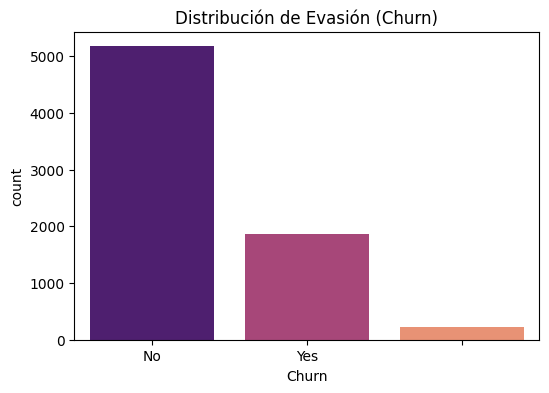

In [366]:
#proporción de clientes que se quedan vs. los que se van
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df_final,hue='Churn', palette='magma')
plt.title('Distribución de Evasión (Churn)')
plt.show()

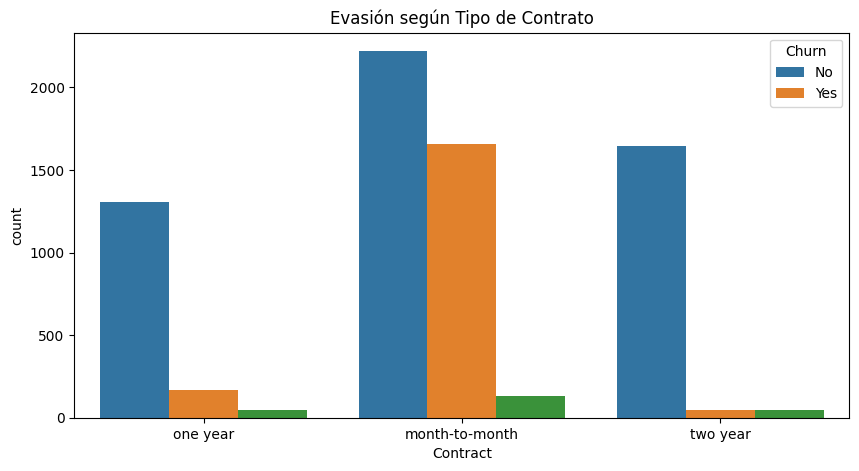

In [357]:
#Gráfico de Churn por Tipo de Contrato
plt.figure(figsize=(10, 5))
sns.countplot(x='Contract', hue='Churn', data=df_final)
plt.title('Evasión según Tipo de Contrato')
plt.show()


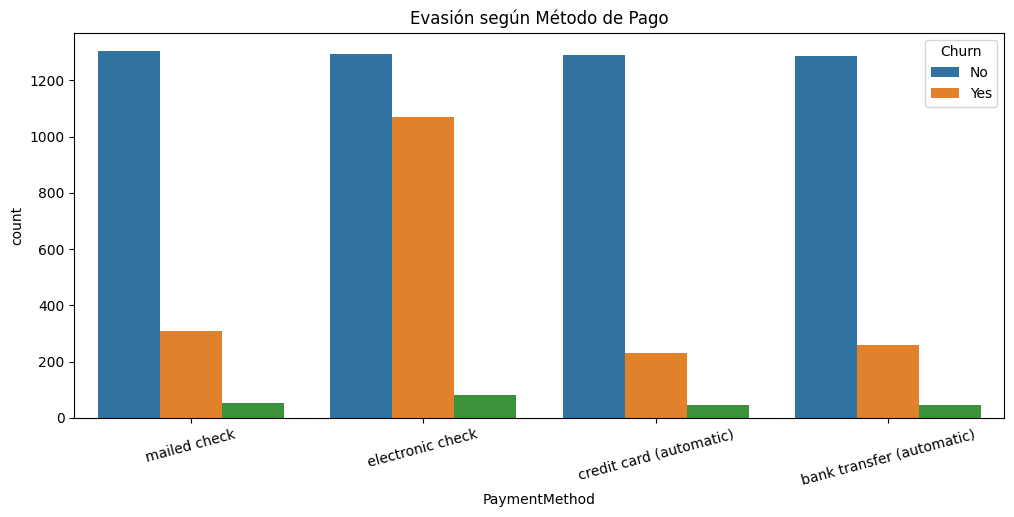

In [358]:
# Gráfico de Churn por Método de Pago
plt.figure(figsize=(12, 5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df_final)
plt.xticks(rotation=15)
plt.title('Evasión según Método de Pago')
plt.show()

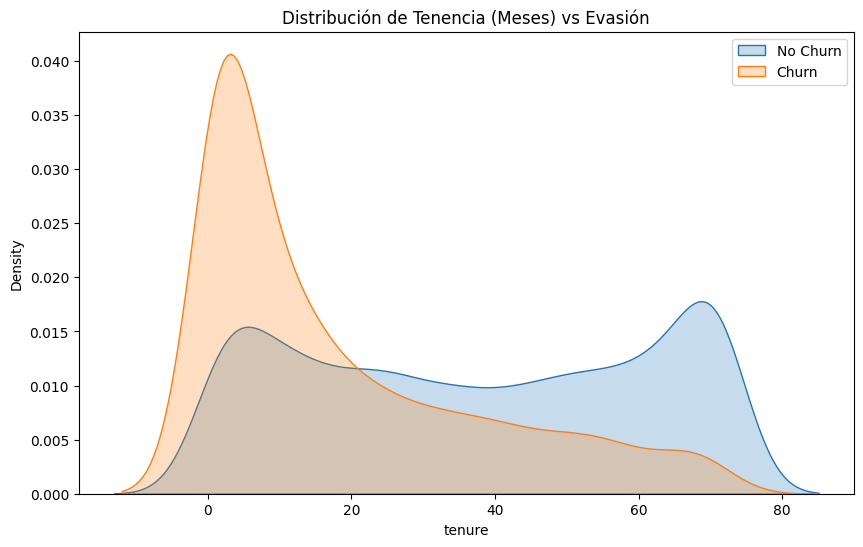

In [367]:
#Los clientes que pagan más se van más rápido?
plt.figure(figsize=(10, 6))
sns.kdeplot(df_final[df_final['Churn'] == 'No']['tenure'], label='No Churn', fill=True)
sns.kdeplot(df_final[df_final['Churn'] == 'Yes']['tenure'], label='Churn', fill=True)
plt.title('Distribución de Tenencia (Meses) vs Evasión')
plt.legend()
plt.show()


#📄Informe final

## **Objetivo**
Entender los motivos por los cuales el 25.7% de nuestros clientes cancela el servicio y proponer acciones inmediatas para frenar esta salida.


---
## **Hallazgos Principales**
#### **Ocurrencias en el primer año**
La mayoría de las cancelaciones ocurren entre el mes 1 y el mes 10.

Si un cliente supera los 12 meses con nosotros, la probabilidad de que se vaya cae drásticamente. Los clientes antiguos son los más leales.

####**contratos "Mes a Mes"**
Los clientes con contratos "Mes a Mes" son los que más abandonan la empresa.
####**Pagos Manuales**
Quienes pagan con "Electronic Check" (pago manual) se van mucho más que quienes tienen Débito Automático.
####**Clientes con servicios en Ciberseguridad**
Aunque el 90% tiene telefonía, solo el 28% cuenta con servicios de seguridad online. Los datos muestran que los clientes con servicios de seguridad tienden a quedarse más tiempo.

| Característica	| Dato Clave |	Observación |
| :--- | :---: | ---: |
| Tasa de Evasión (Churn)	| 25.7%	| Es una cifra alta; 1 de cada 4 clientes se va. |
| Gasto Promedio Mensual	| $64.72	| Los que pagan más no necesariamente se van más rápido. |
| Segmento Adulto Mayor	| 16.2%	| Son una minoría en la base actual; potencial de crecimiento. |
| Género	| 49.43/50.57| No hay una diferencia importante; mujeres y hombres representan casi el mismo porcentaje |


###**Conclusiones**

La fuga de clientes no es al azar. **El perfil de alto riesgo es: un cliente nuevo, con contrato mes a mes**, que usa fibra óptica y paga manualmente. Es probable que la fibra óptica esté generando expectativas de precio o estabilidad que no se están cumpliendo en esos primeros meses críticos.